# Feature Target Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ssdf.config import FEATURES_DATA_DIR

## Load Data & Preprocessing
Merge targets and features, create date variables, and compute lags (1 to 16).

In [2]:
target = pd.read_parquet(FEATURES_DATA_DIR / "target.parquet")
features = pd.read_parquet(FEATURES_DATA_DIR / "features.parquet")

df = target.merge(features, on=["date", "unique_id"], how="inner")
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.day_name()

# Create lags 1 to 16
for i in range(1, 17):
    df[f"sales_lag_{i}"] = df.groupby("unique_id")["sales"].shift(i)

df = df.dropna()

## Target Distribution
Plotting the distribution of the target (sales).

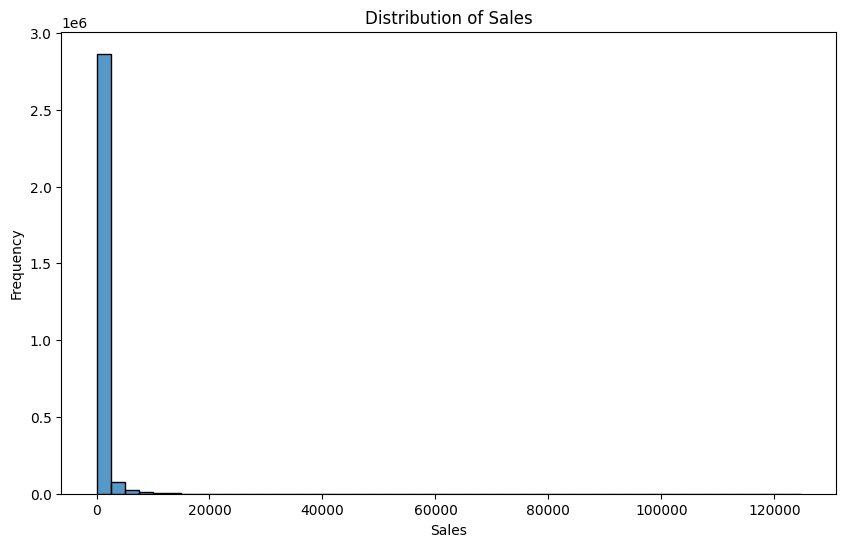

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sales'], bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

## Feature Distribution
Plotting the distribution of the features: `store_nbr`, `family`, and `onpromotion`.

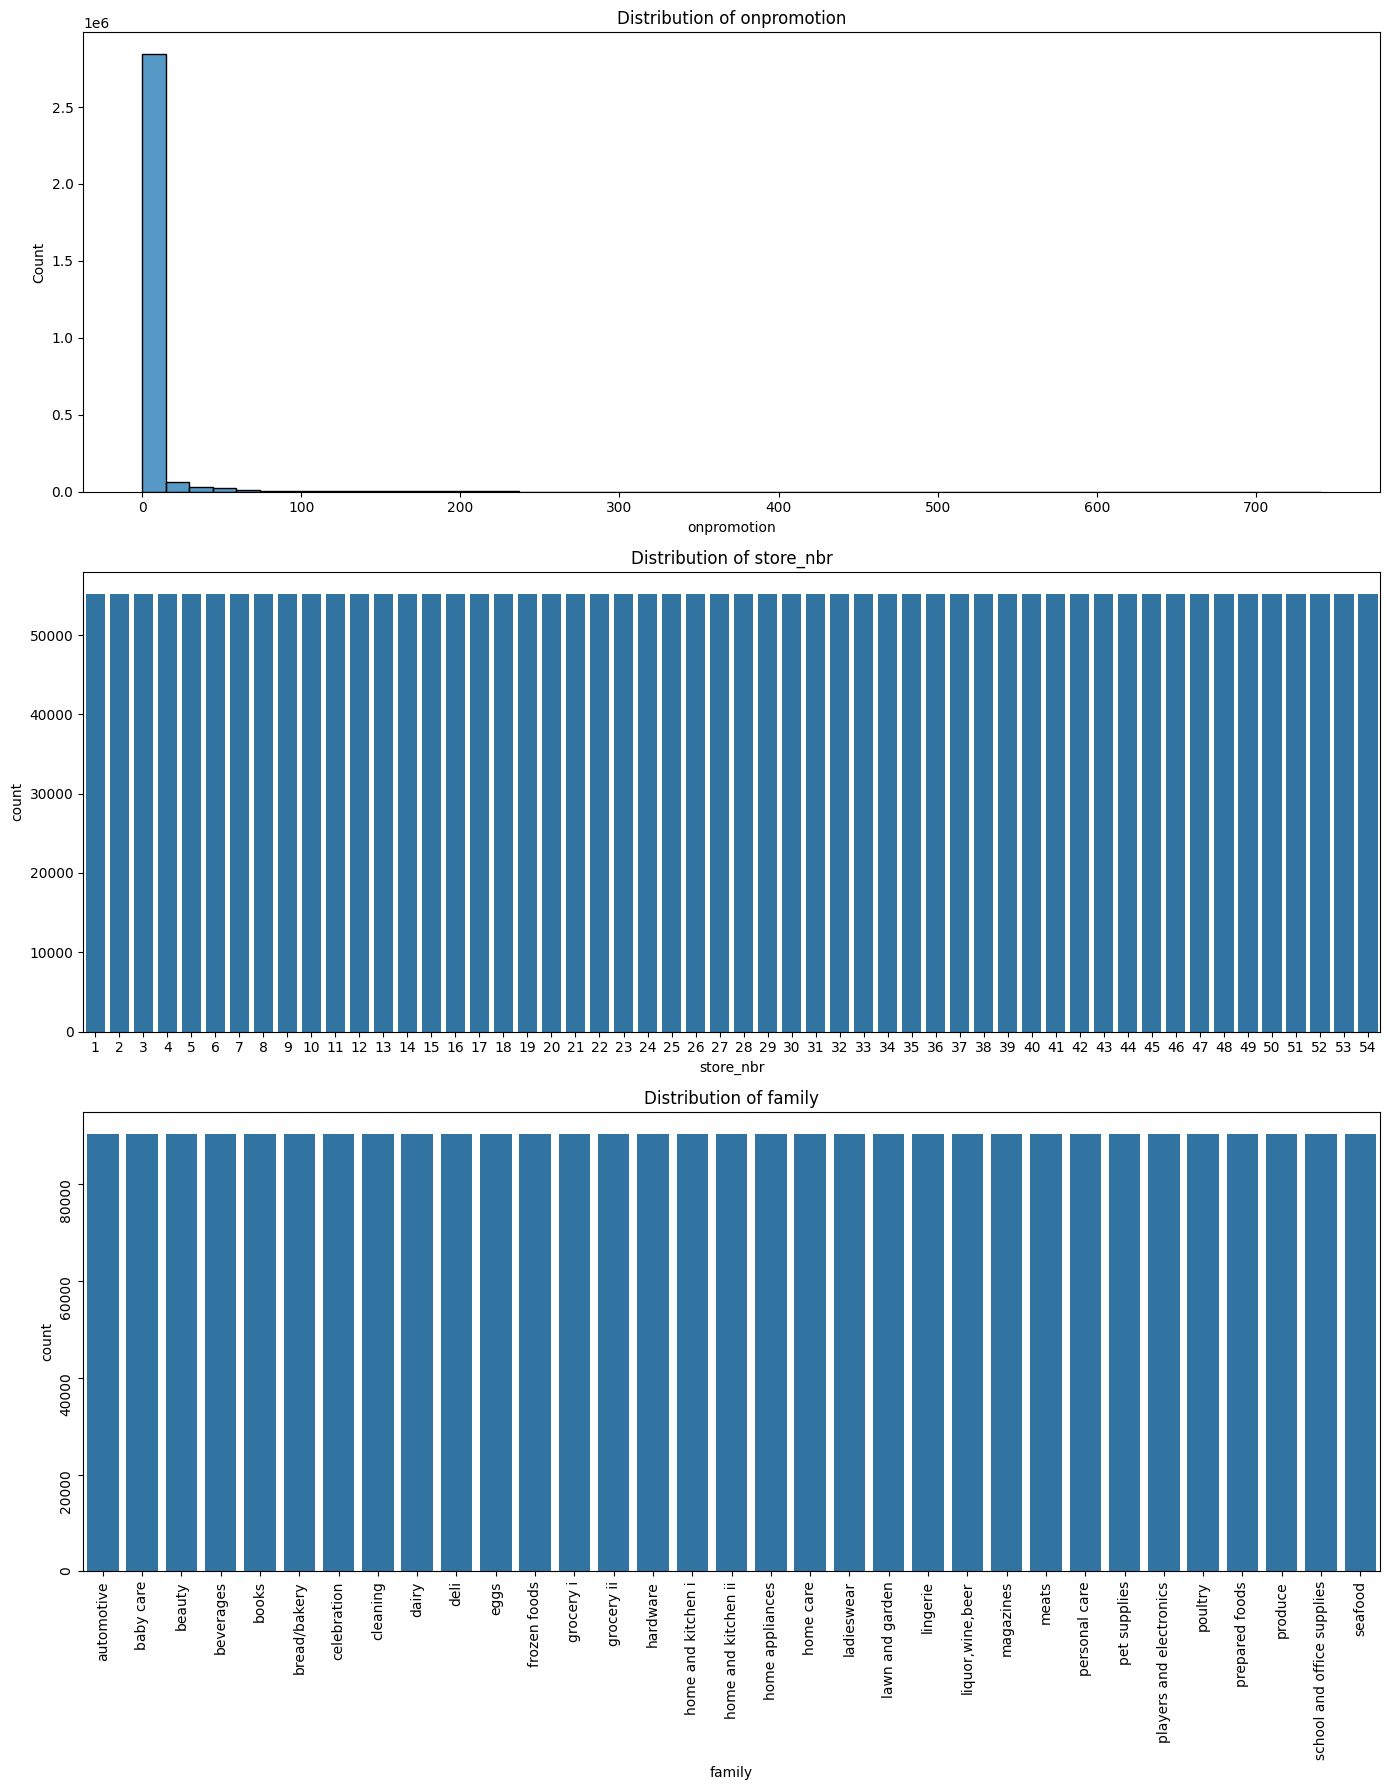

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# On Promotion Distribution
sns.histplot(data=df, x="onpromotion", ax=axes[0], bins=50)
axes[0].set_title("Distribution of onpromotion")

# Store Number Distribution
sns.countplot(data=df, x="store_nbr", ax=axes[1])
axes[1].set_title("Distribution of store_nbr")

# Family Distribution
sns.countplot(data=df, x="family", ax=axes[2])
axes[2].set_title("Distribution of family")
axes[2].tick_params(labelrotation=90)

plt.tight_layout()
plt.show()

## Explore Relationships: Numerical Features
Plot heatmap of `sales`, lags (1 to 16), and `onpromotion` feature.

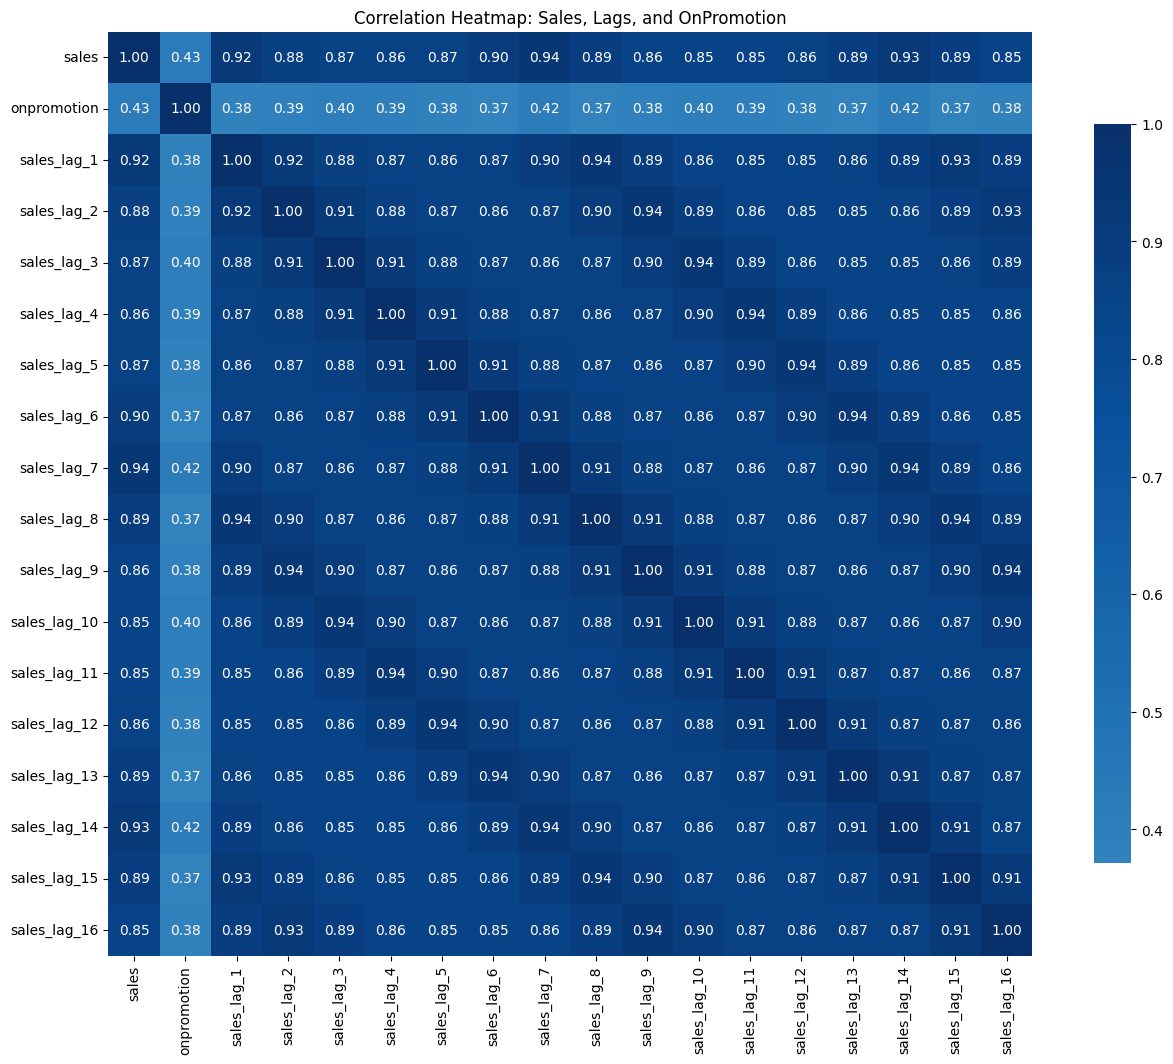

In [5]:
num_cols = ["sales", "onpromotion"] + [f"sales_lag_{i}" for i in range(1, 17)]
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0.0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap: Sales, Lags, and OnPromotion")
plt.show()

As seen in the autocorrelation plot of the average daily sales across stores (see `avg-sales-eda.ipynb`), the lags of the sale are highly correlated with its future value.

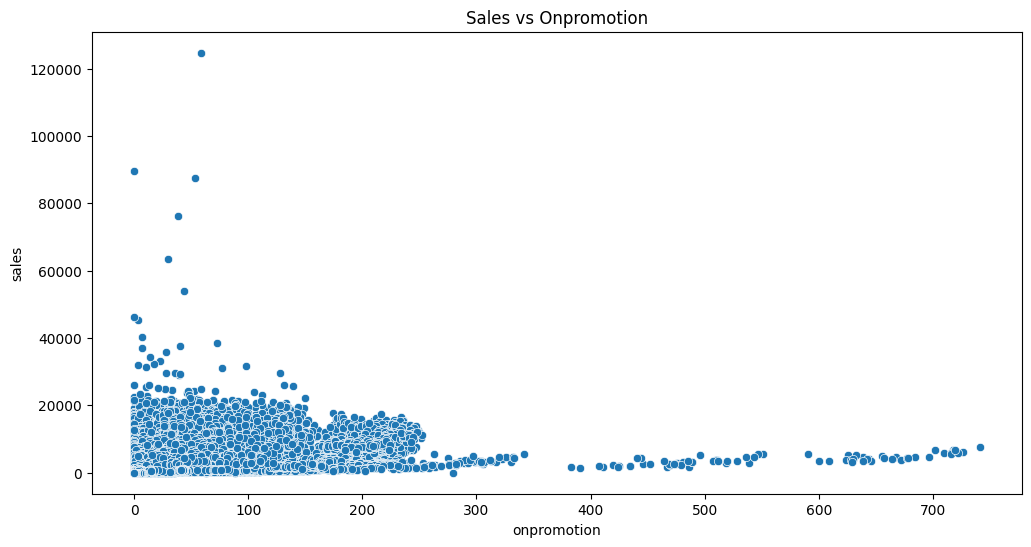

In [6]:
plt.figure(figsize=(12, 6))
sns.scatterplot(df, y="sales", x="onpromotion")
plt.title("Sales vs Onpromotion");

## Explore Relationships: Categorical Features
Plot the average value of target by category (`store_nbr`, `family`, `day_of_week`).

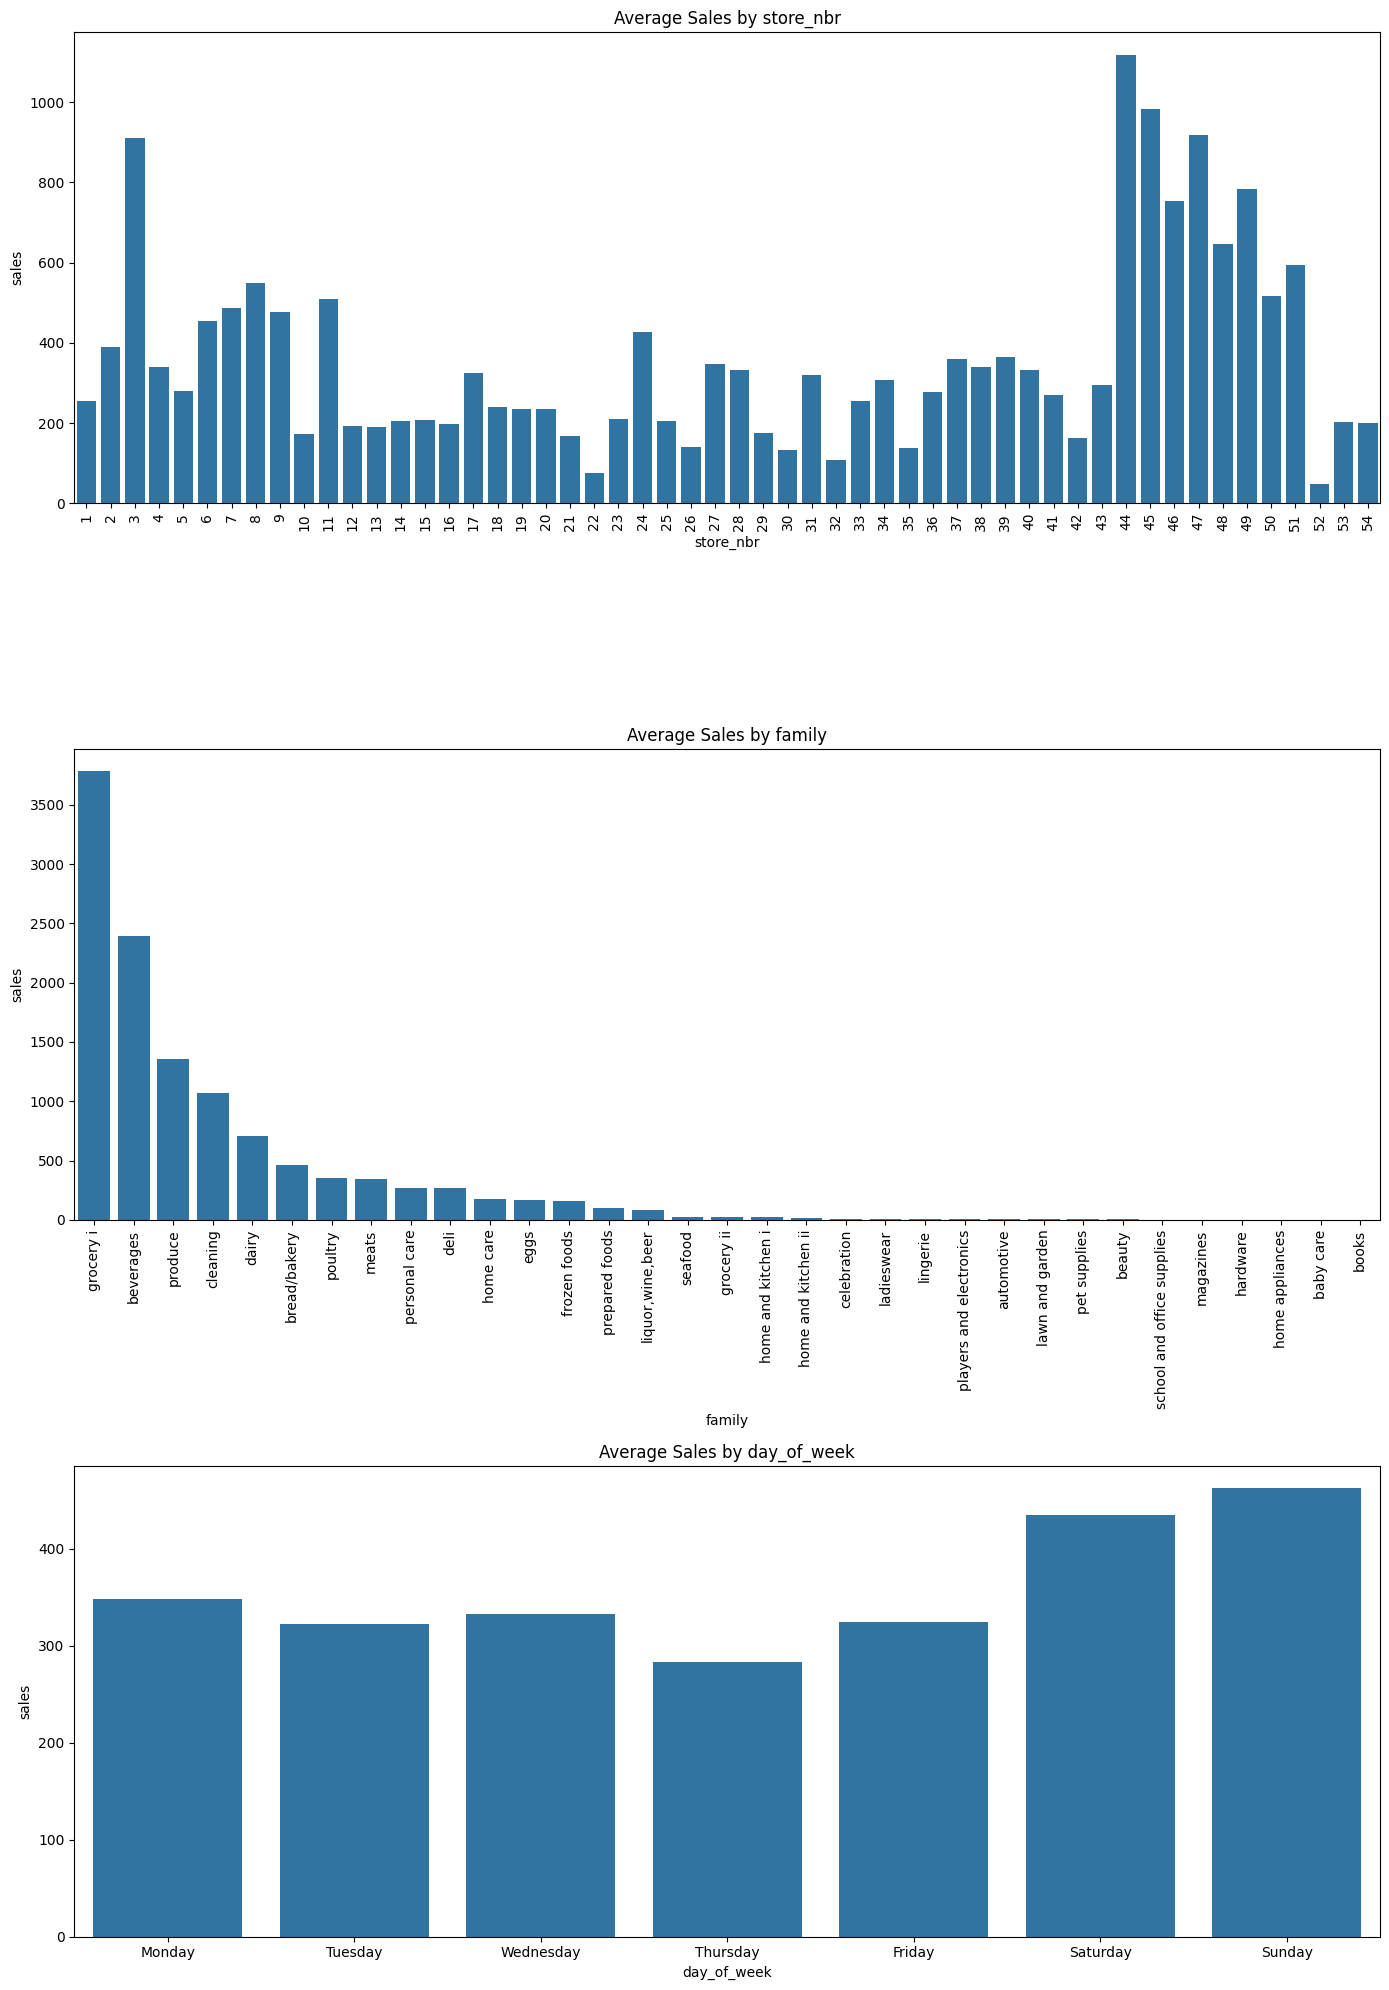

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 20))

# Average Sales by Store Number
store_sales = df.groupby("store_nbr")["sales"].mean().reset_index()
sns.barplot(data=store_sales, x="store_nbr", y="sales", ax=axes[0])
axes[0].set_title("Average Sales by store_nbr")
axes[0].tick_params(axis="x", rotation=90)

# Average Sales by Family
family_sales = (
    df.groupby("family")["sales"]
    .mean()
    .reset_index()
    .sort_values("sales", ascending=False)
)
sns.barplot(data=family_sales, x="family", y="sales", ax=axes[1])
axes[1].set_title("Average Sales by family")
axes[1].tick_params(axis="x", rotation=90)

# Average Sales by Day of Week
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_sales = df.groupby("day_of_week")["sales"].mean().reindex(day_order).reset_index()
sns.barplot(
    data=day_sales,
    x="day_of_week",
    y="sales",
    ax=axes[2],
    order=day_order,
)
axes[2].set_title("Average Sales by day_of_week")

plt.tight_layout()
plt.show()

There are variabilities in the target feature that the model can learn from, hence using the feature to train a model might be helpful.